<a href="https://colab.research.google.com/github/himanshi0814/Autism_prediction/blob/main/Autism_prediction_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Importing the dependencies**







In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle



## 2.Data Loading & Understanding

In [ ]:
#read the csv data to pandas data frame
df = pd.read_csv("/content/train.csv")

3.Initial Inspection

In [ ]:
df.shape

(800, 22)

In [ ]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [ ]:
df.tail()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
795,796,0,1,0,0,0,0,0,0,1,1,16.597187,m,Hispanic,no,no,New Zealand,no,12.999501,18 and more,Self,0
796,797,0,1,1,0,0,1,0,1,1,1,20.703001,m,White-European,no,no,Cyprus,no,13.561518,18 and more,Self,0
797,798,0,0,0,0,0,0,0,0,0,0,5.711481,m,South Asian,yes,no,New Zealand,no,2.653177,18 and more,Self,0
798,799,0,0,0,0,0,0,0,0,0,0,16.414305,f,?,no,no,Canada,no,9.069342,18 and more,Self,0
799,800,0,1,0,0,0,0,0,0,0,0,46.966113,f,?,no,no,United Arab Emirates,yes,2.243304,18 and more,Self,0


In [ ]:
#display all columns of a dataset
pd.set_option('display.max_columns',None)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [ ]:
#convert age column  datatype to integer
df["age"] = df["age"].astype(int)

In [ ]:
df.head(2)

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,18 and more,Self,0


In [ ]:
for col in df.columns:
  numerical_features = ["10","age","result"]
  if col not in numerical_features:
    print(col,df[col].unique())
    print("-"*50)

ID [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246

In [ ]:
#dropping ID & age desc column
df = df.drop(columns =["ID","age_desc"])

In [ ]:
df.shape

(800, 20)

In [ ]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0


In [ ]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [ ]:
df["contry_of_res"].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Viet Nam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'AmericanSamoa', 'Bahamas', 'Saudi Arabia',
       'Ireland', 'Aruba', 'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan',
       'Armenia', 'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'Hong Kong',
       'Angola', 'China', 'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran',
       'Argentina', 'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone',
       'Czech Republic', 'Niger', 'Romania', 'Cyprus', 'Belgium',
       'Burundi', 'Bangladesh'], dtype=object)

In [ ]:
# define the mapping dictionary for country name
mapping = {
    "Viet Nam":"Vietnam",
    "AmericanSamoa":"United States",
    "Hong Kong": "China"
}
# replace value in country column
df["contry_of_res"]= df["contry_of_res"].replace(mapping)


In [ ]:
df["contry_of_res"].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Vietnam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'Bahamas', 'Saudi Arabia', 'Ireland', 'Aruba',
       'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan', 'Armenia',
       'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'China', 'Angola',
       'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran', 'Argentina',
       'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone', 'Czech Republic',
       'Niger', 'Romania', 'Cyprus', 'Belgium', 'Burundi', 'Bangladesh'],
      dtype=object)

In [ ]:
#target class distribution
df["Class/ASD"].value_counts()

,count
Class/ASD,
0,639
1,161


**Insights**
1. missing values in ethnicity & relation
2. age_desc column has only 1 unique value, so it is removed as it is not important for prediction
3. fixed country names
4. identified class imbalance in the target column

**3.Exploratory Data Analysis**

In [ ]:
df.shape

(800, 20)

In [ ]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [ ]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,Self,0


In [ ]:
df.describe()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,28.452118,8.537303,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.310966,4.807676,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.718550,-6.137748,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.198153,5.306575,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.848350,9.605299,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.865429,12.514484,0.000000
max,800.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.461718,15.853126,1.000000


Univariate Analysis

Numerical Columns:

*   age
*   result



In [ ]:
import seaborn as sns
# set the desired theme
sns.set_theme(style = "whitegrid")

Distribution Plots

Mean: 28.452117626575
Median: 24.848350449999998


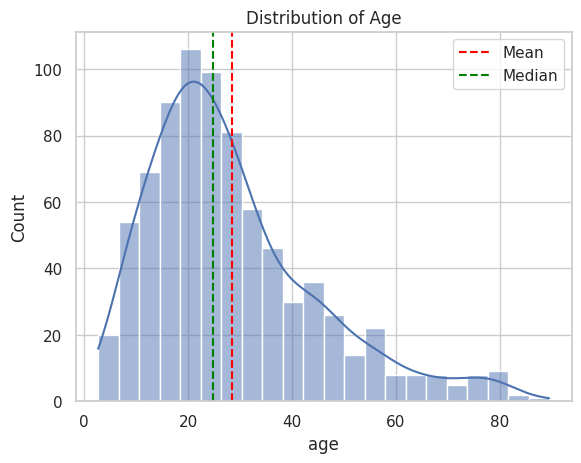

In [ ]:
from matplotlib.lines import lineStyles
#Histogram for "age"
sns.histplot(df["age"],kde = True)
plt.title("Distribution of Age")

# Calculate Mean and Median
age_mean = df["age"].mean()
age_median=df["age"].median()

print("Mean:",age_mean)
print("Median:",age_median)

# add vertical lines for mean and median
plt.axvline(age_mean, color="red",linestyle="--",label="Mean")
plt.axvline(age_median, color="green",linestyle="--",label="Median")
plt.legend()
plt.show()


Mean: 8.537303106501248
Median: 9.605299308


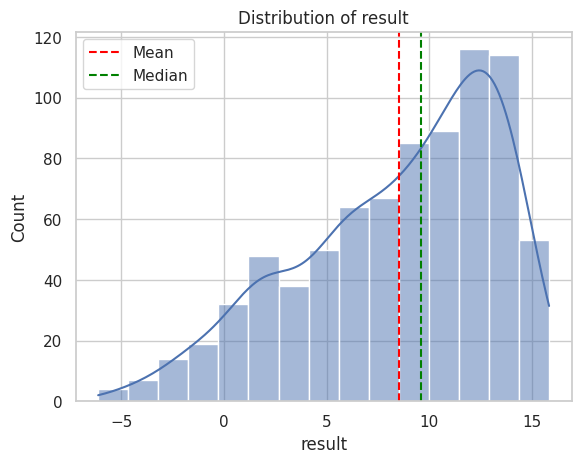

In [ ]:
#Histogram for result
sns.histplot(df["result"],kde = True)
plt.title("Distribution of result")

# Calculate Mean and Median
result_mean = df["result"].mean()
result_median=df["result"].median()

print("Mean:",result_mean)
print("Median:",result_median)

# add vertical lines for mean and median
plt.axvline(result_mean, color="red",linestyle="--",label="Mean")
plt.axvline(result_median, color="green",linestyle="--",label="Median")
plt.legend()
plt.show()



**Box plots for identifying outliers in the numerical column **

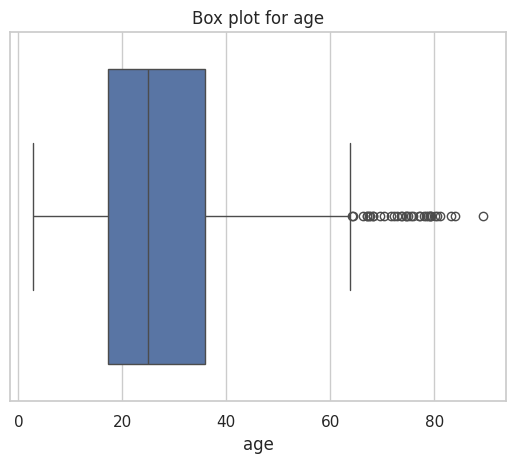

In [ ]:
#box plot:age
sns.boxplot(x=df["age"])
plt.title("Box plot for age")
plt.xlabel("age")
plt.show()

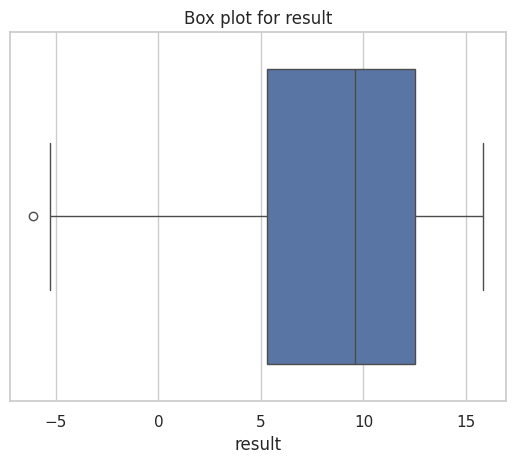

In [ ]:
#box plot:result
sns.boxplot(x=df["result"])
plt.title("Box plot for result")
plt.xlabel("result")
plt.show()


In [ ]:
#count the outliers using IQR method:age
Q1=df["age"].quantile(0.25)
Q3=df["age"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
age_outliers = df[(df["age"]<lower_bound) | (df["age"]>upper_bound)]


In [ ]:
len(age_outliers)

35

In [ ]:
#count the outliers using IQR method:result
Q1=df["result"].quantile(0.25)
Q3=df["result"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
result_outliers = df[(df["result"]<lower_bound) | (df["result"]>upper_bound)]

In [ ]:
len(result_outliers)

1

Univariate analysis of categorical column

In [ ]:
df.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

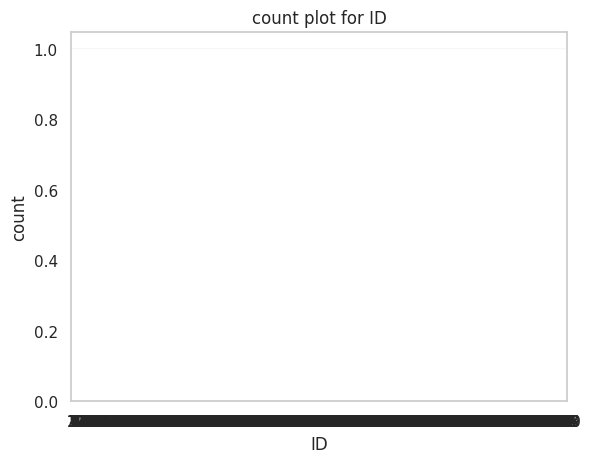

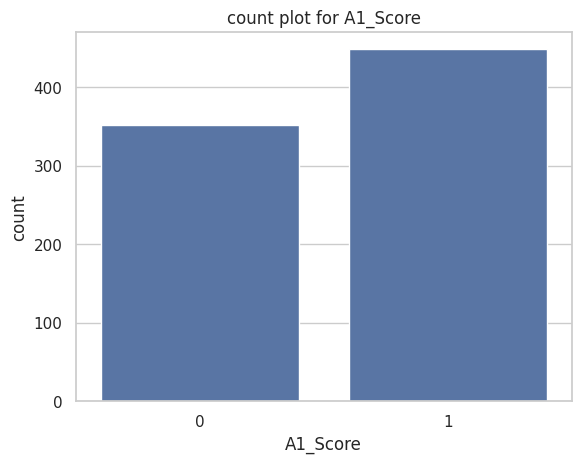

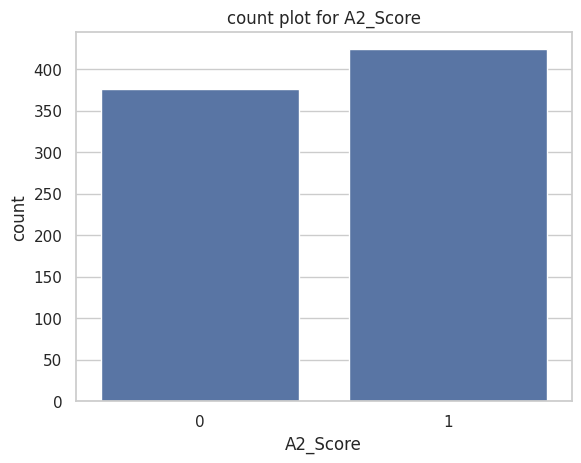

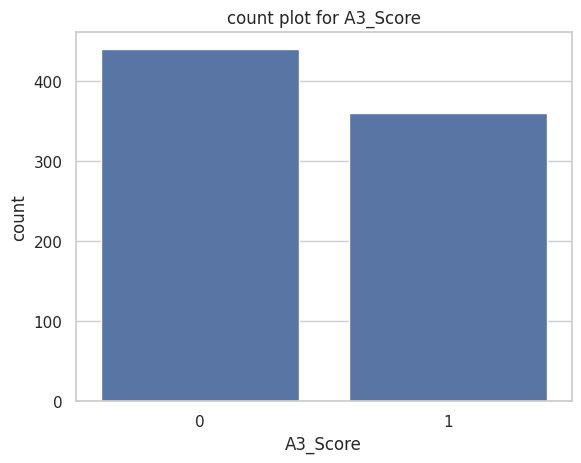

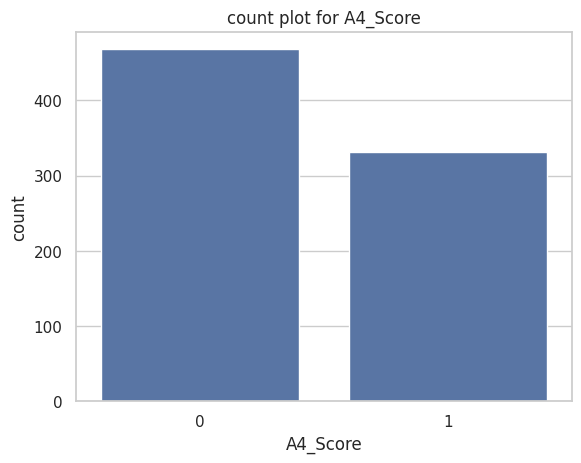

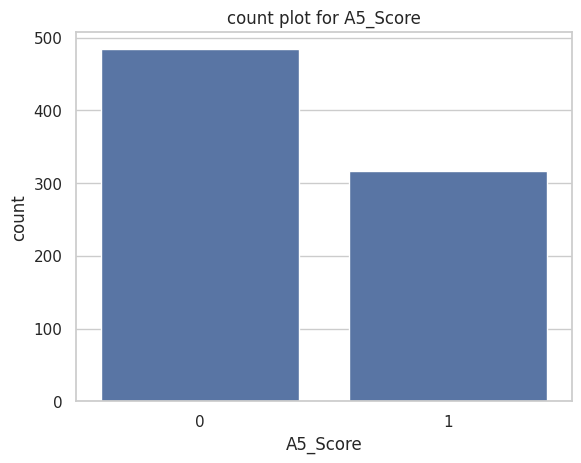

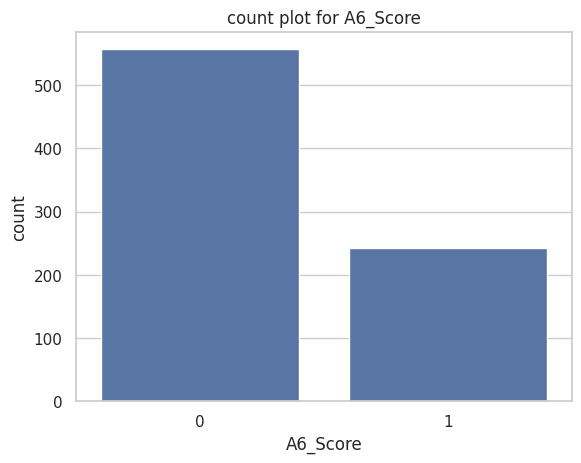

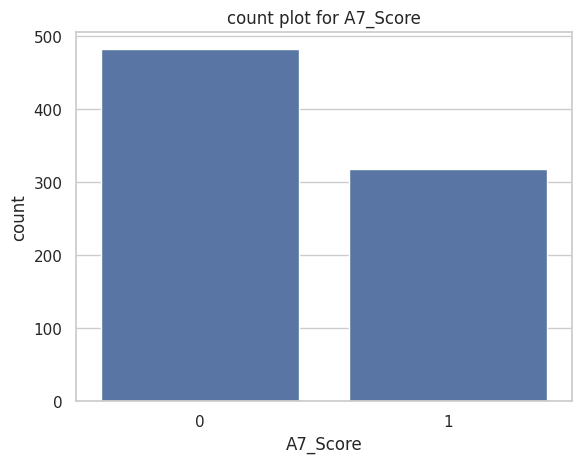

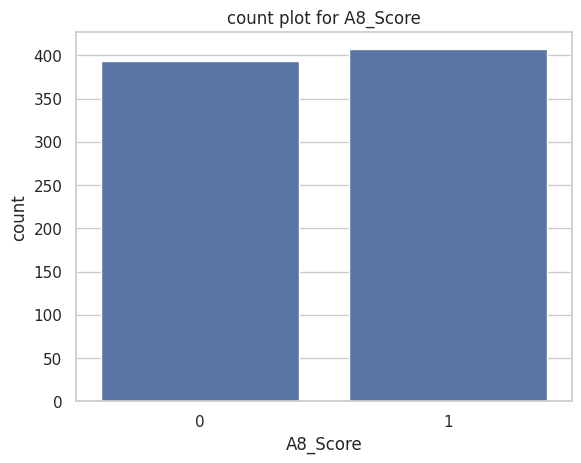

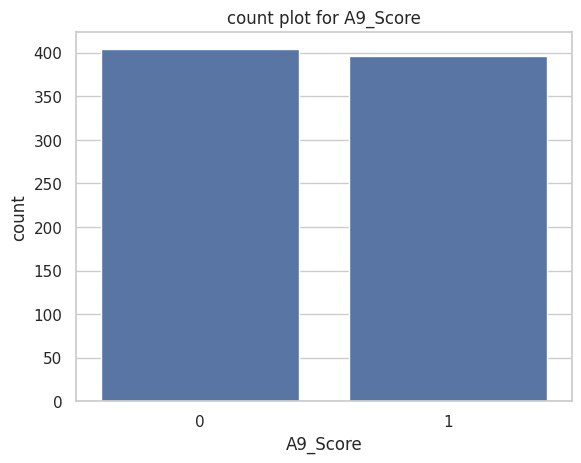

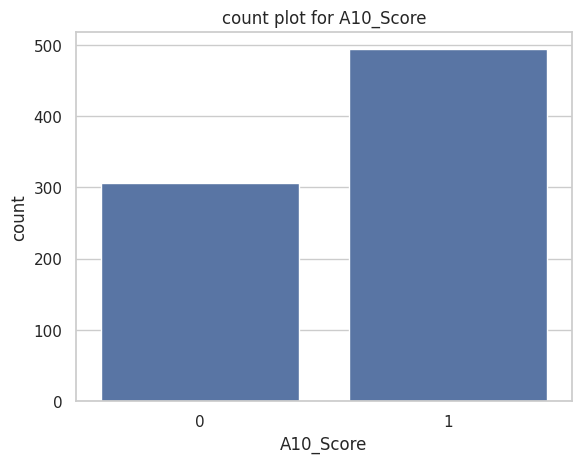

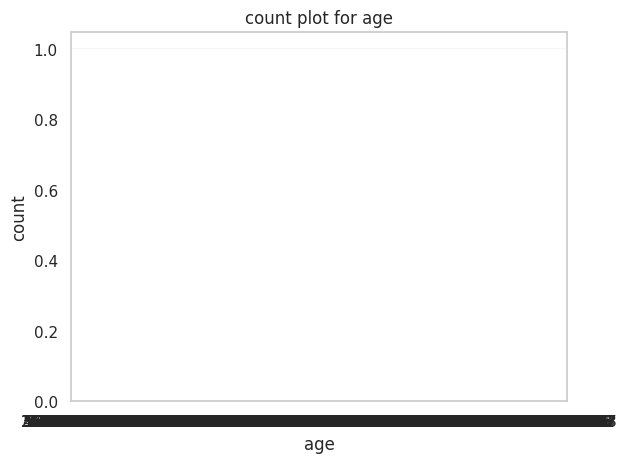

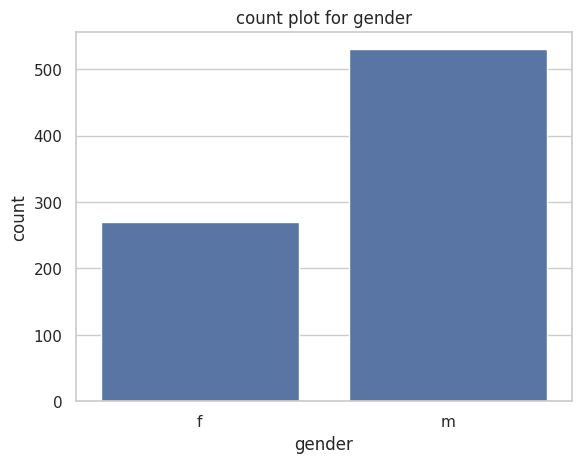

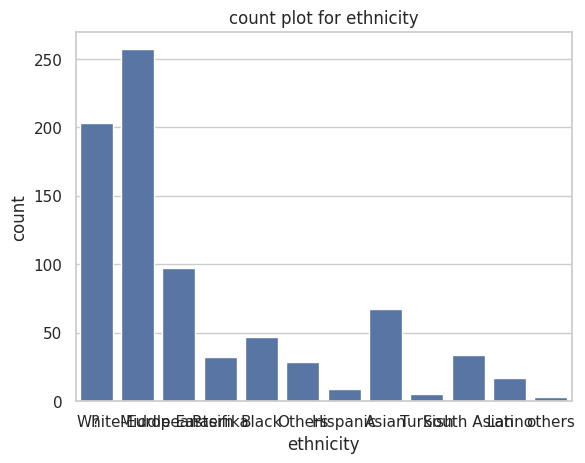

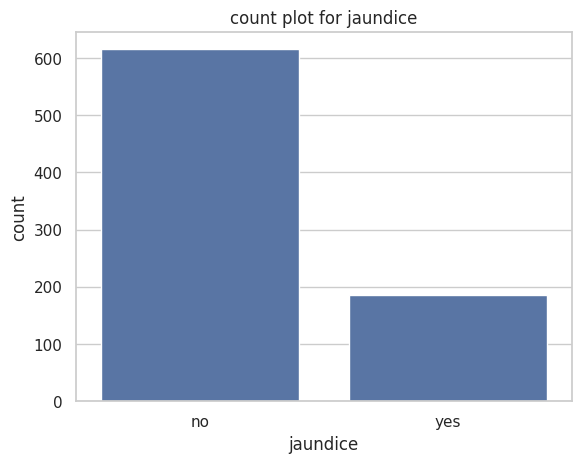

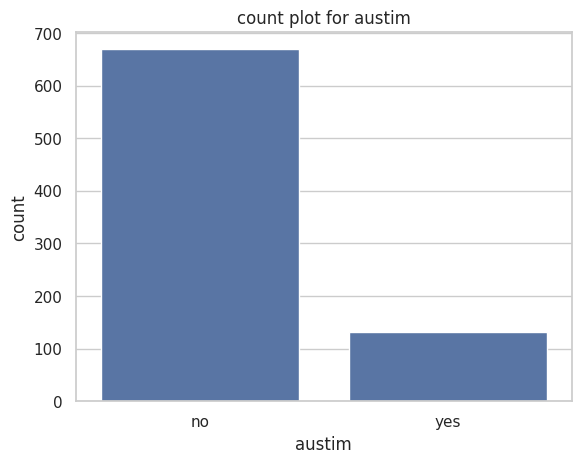

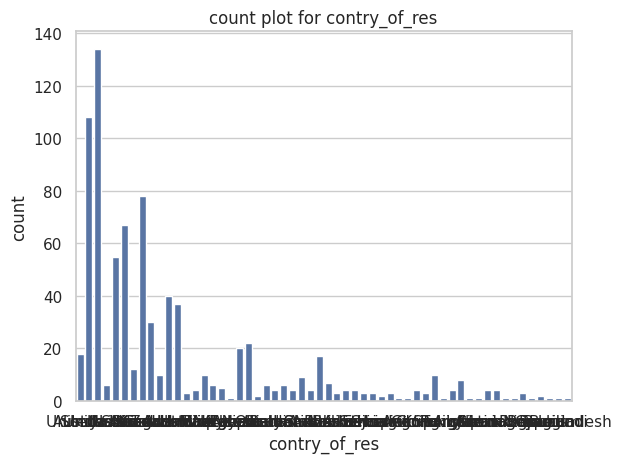

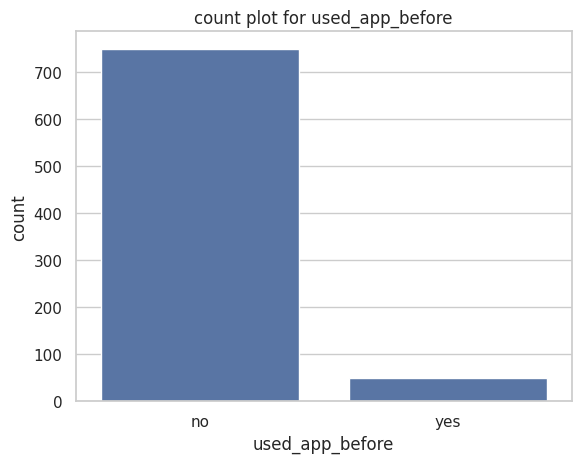

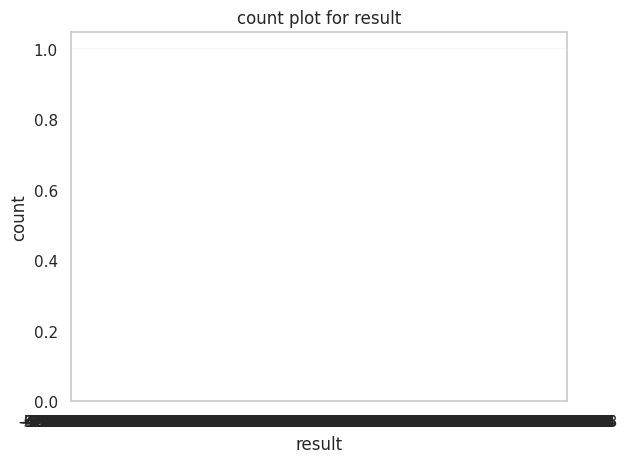

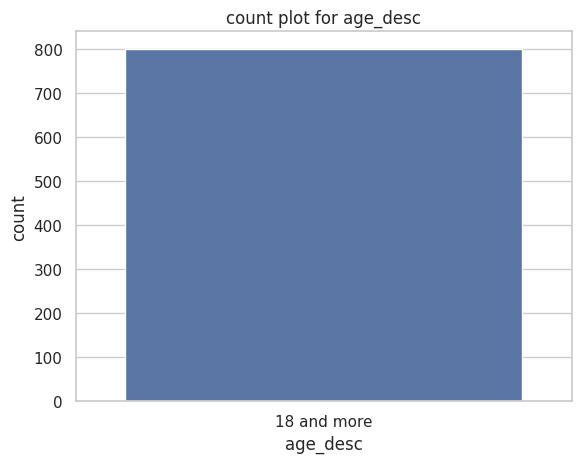

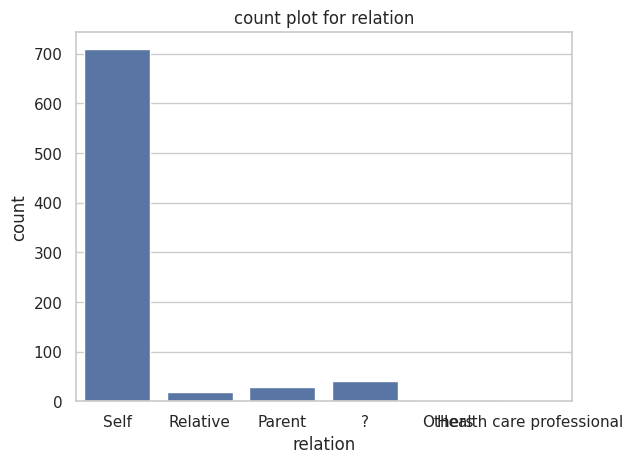

In [ ]:
Categorical_Columns = ['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation']
for  col in Categorical_Columns:
  sns.countplot(x=df[col])
  plt.title(f"count plot for {col}")
  plt.xlabel(col)
  plt.ylabel("count")
  plt.show()


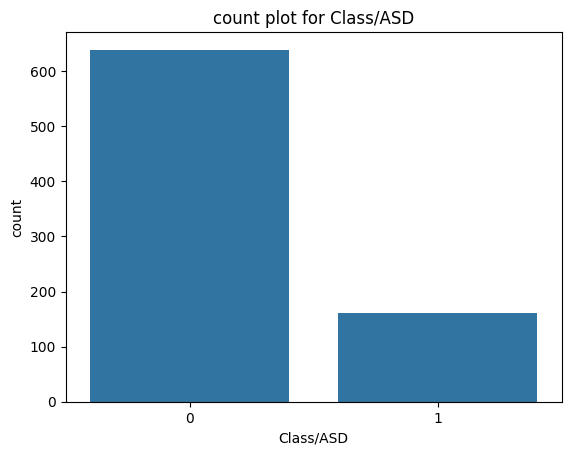

In [ ]:
#count plot for target column (class/asd)
sns.countplot(x=df["Class/ASD"])
plt.title("count plot for Class/ASD")
plt.xlabel("Class/ASD")
plt.ylabel("count")
plt.show()

In [ ]:
df["Class/ASD"].value_counts()

,count
Class/ASD,
0,639
1,161


handle missing value in ethnicity and relation column

In [ ]:
df["ethnicity"]=df["ethnicity"].replace({"?":"Others", "others":"Others"})

In [ ]:
df["ethnicity"].unique()

array(['Others', 'White-European', 'Middle Eastern ', 'Pasifika', 'Black',
       'Hispanic', 'Asian', 'Turkish', 'South Asian', 'Latino'],
      dtype=object)

In [ ]:
df["relation"].unique()

array(['Self', 'Relative', 'Parent', '?', 'Others',
       'Health care professional'], dtype=object)

In [ ]:
df["relation"] = df["relation"].replace(
    {"?":"Others",
     "Relative":"Others",
     "Health care professional":"Others"
    }
)

In [ ]:
df["relation"].unique()

array(['Self', 'Others', 'Parent'], dtype=object)

In [ ]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,Others,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,Others,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,Others,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,Others,no,no,South Africa,no,-4.777286,18 and more,Self,0


Label Encoding

In [ ]:
#identify columns with "object " data type
object_columns = df.select_dtypes(include=["object"]).columns

In [ ]:
print(object_columns)

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'age_desc', 'relation'],
      dtype='object')


In [ ]:
#initialize  a dictionary to store the encoders
encoders ={}
# apply  label encodingg and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder #saving the encoder for this column
  #save the encoders as a pickle file
  with open("label_encoders.pkl","wb") as f:
    pickle.dump(encoders,f)

In [ ]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'age_desc': LabelEncoder(),
 'relation': LabelEncoder()}

In [ ]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,0,5,0,0,7,0,6.351166,0,2,0
1,2,0,0,0,0,0,0,0,0,0,...,1,5,0,0,25,0,2.255185,0,2,0
2,3,1,1,1,1,1,1,1,1,1,...,1,9,0,1,54,0,14.851484,0,2,1
3,4,0,0,0,0,0,0,0,0,0,...,0,5,0,0,54,0,2.276617,0,2,0
4,5,0,0,0,0,0,0,0,0,0,...,1,5,0,0,46,0,-4.777286,0,2,0


Bivariate Analysis

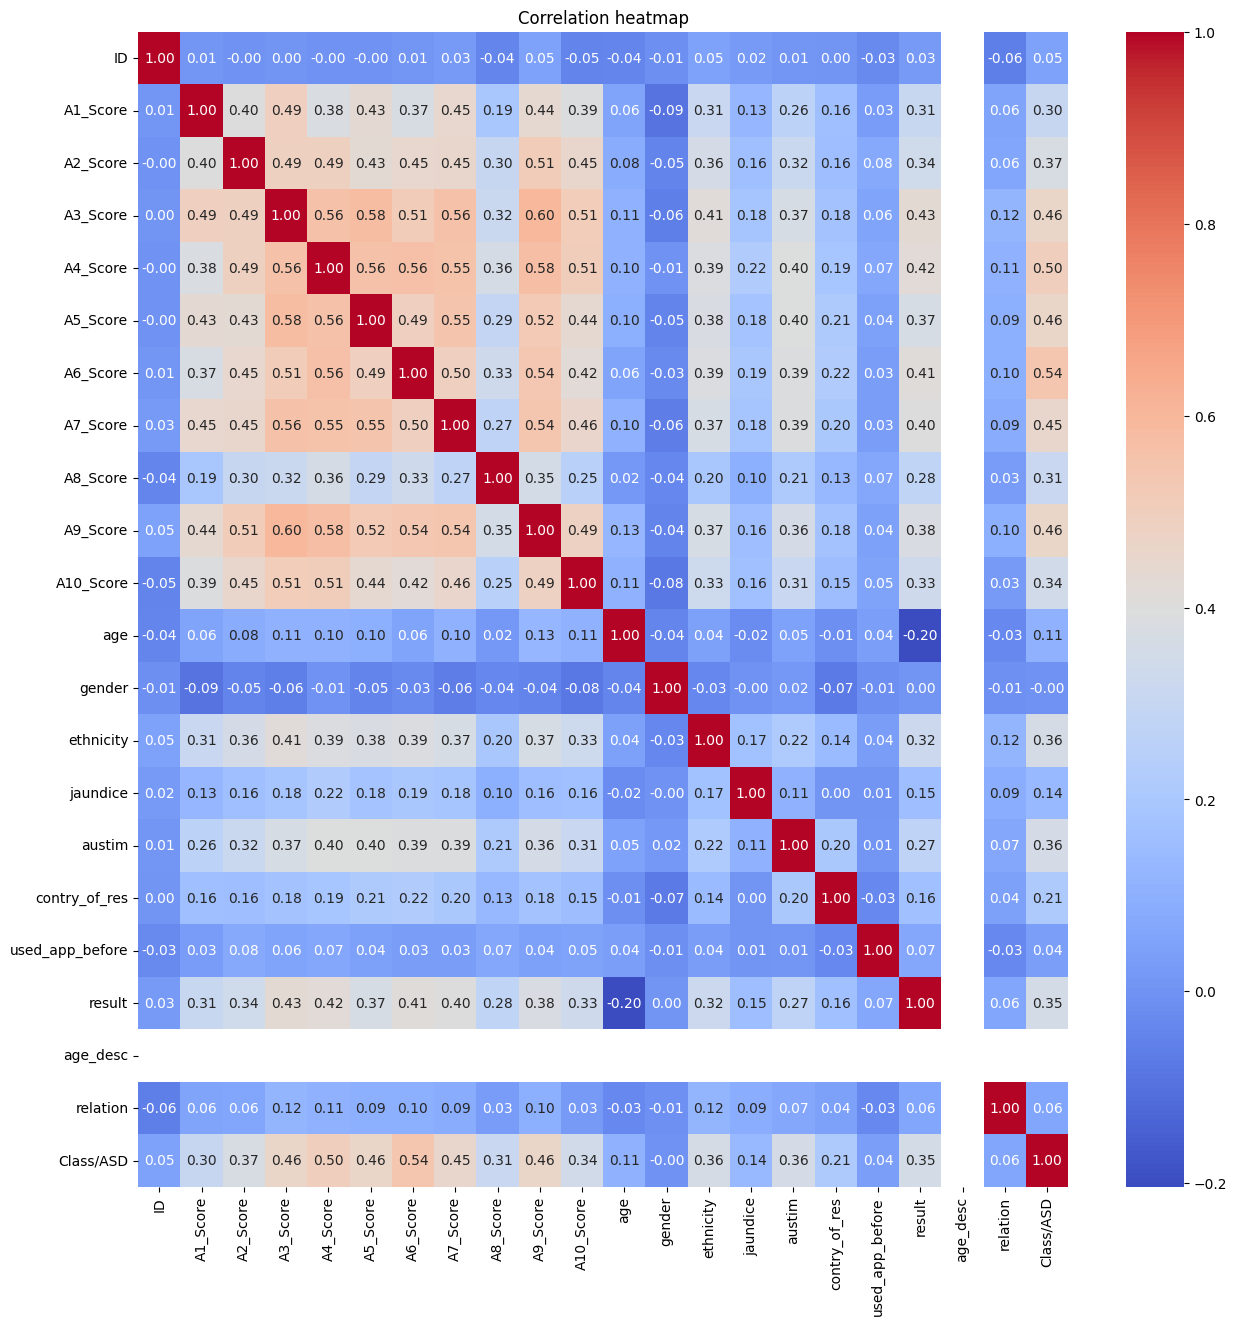

In [ ]:
# correlation matrix
plt.figure(figsize =(15,15))
sns.heatmap(df.corr(),annot = True,cmap="coolwarm",fmt = ".2f")
plt.title("Correlation heatmap")
plt.show()

**Insights from EDA**


*   There are few outliers in the numerical columns (age,results)

*   There is a class imbalance inn the target column

*   There is a class imbalance in the categorical features
*   we do not have any highly correlated column


*   performed label encoding and saved the encoders






**4. Data Preprocessing**

Handling the outliers

In [ ]:
#function to replace the outliers with median
def replace_outliers_with_median(df,column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3-Q1

  lower_bound = Q1-1.5*IQR
  upper_bound = Q3 +1.5*IQR

  median = df[column].median()
  #replace outliers with median value
  df[column] = df[column].apply(lambda x:median if x<lower_bound or x>upper_bound else x)

  return df


In [ ]:
#replace outliers in the age column
df = replace_outliers_with_median(df,"age")
#replace outliers in the "result"column
df = replace_outliers_with_median(df,"result")

In [ ]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,0,5,0,0,7,0,6.351166,0,2,0
1,2,0,0,0,0,0,0,0,0,0,...,1,5,0,0,25,0,2.255185,0,2,0
2,3,1,1,1,1,1,1,1,1,1,...,1,9,0,1,54,0,14.851484,0,2,1
3,4,0,0,0,0,0,0,0,0,0,...,0,5,0,0,54,0,2.276617,0,2,0
4,5,0,0,0,0,0,0,0,0,0,...,1,5,0,0,46,0,-4.777286,0,2,0


In [ ]:
df.shape

(800, 22)

**Train Test Split**

In [ ]:
df.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [ ]:
# Create a copy of the dataframe to ensure all preprocessing is applied before creating X and y
processed_df = df.copy()

# Ensure ID and age_desc are dropped if they are still present
if 'ID' in processed_df.columns:
    processed_df = processed_df.drop(columns=["ID"])
if 'age_desc' in processed_df.columns:
    processed_df = processed_df.drop(columns=["age_desc"])

# Identify object columns for encoding. This will capture 'gender', 'ethnicity', etc.
object_columns_to_encode = processed_df.select_dtypes(include=["object"]).columns

# Apply Label Encoding to all identified object columns
if len(object_columns_to_encode) > 0:
    label_encoder = LabelEncoder()
    for col in object_columns_to_encode:
        processed_df[col] = label_encoder.fit_transform(processed_df[col])

X = processed_df.drop(columns=["Class/ASD"])
y = processed_df["Class/ASD"]


In [ ]:
print(X)

     A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0           1         0         1         0         1         0         1   
1           0         0         0         0         0         0         0   
2           1         1         1         1         1         1         1   
3           0         0         0         0         0         0         0   
4           0         0         0         0         0         0         0   
..        ...       ...       ...       ...       ...       ...       ...   
795         0         1         0         0         0         0         0   
796         0         1         1         0         0         1         0   
797         0         0         0         0         0         0         0   
798         0         0         0         0         0         0         0   
799         0         1         0         0         0         0         0   

     A8_Score  A9_Score  A10_Score        age  gender  ethnicity  jaundice 

In [ ]:
print(y)

0      0
1      0
2      1
3      0
4      0
      ..
795    0
796    0
797    0
798    0
799    0
Name: Class/ASD, Length: 800, dtype: int64


In [ ]:
X_train, X_test,y_train,y_test = train_test_split( X ,y,test_size=0.2, random_state = 42)

In [ ]:
print(y_train.shape)
print(y_test.shape)

(640,)
(160,)


In [ ]:
y_train.value_counts()

,count
Class/ASD,
0,515
1,125


In [ ]:
y_test.value_counts()

,count
Class/ASD,
0,124
1,36


SMOTE(synthetic Minority Oversampling Technique)

In [ ]:
smote = SMOTE(random_state=42)

In [ ]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
print(y_train_smote.shape)

(1030,)


In [ ]:
print(y_train_smote.value_counts())

Class/ASD
1    515
0    515
Name: count, dtype: int64


**5. Model Training **

In [ ]:
#dictionary classifiers
models ={
    "Decision Tree":DecisionTreeClassifier(random_state = 42),
    "Random Forest":RandomForestClassifier(random_state = 42),
    "XGBoost":XGBClassifier(random_state = 42)
}


In [ ]:
print(models)

{'Decision Tree': DecisionTreeClassifier(random_state=42), 'Random Forest': RandomForestClassifier(random_state=42), 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)}


In [ ]:
#dictionary to store the cross validiation results
cv_scores={}
#perform 5-fold cross validiation for each model
for model_name,model in models.items():
  print(f"Training {model_name}with default parameters....")
  scores = cross_val_score(model,X_train_smote,y_train_smote,cv=5,scoring = "accuracy")
  cv_scores [model_name] = scores
  print(f"{model_name} Cross Validiation A ccuracy:{np.mean(scores):.2f}")
  print("-"*50)

Training Decision Treewith default parameters....
Decision Tree Cross Validiation A ccuracy:0.86
--------------------------------------------------
Training Random Forestwith default parameters....
Random Forest Cross Validiation A ccuracy:0.91
--------------------------------------------------
Training XGBoostwith default parameters....
XGBoost Cross Validiation A ccuracy:0.90
--------------------------------------------------


In [ ]:
cv_scores

{'Decision Tree': array([0.82038835, 0.88349515, 0.86407767, 0.88349515, 0.86893204]),
 'Random Forest': array([0.87378641, 0.9368932 , 0.90291262, 0.91747573, 0.91262136]),
 'XGBoost': array([0.87864078, 0.93203883, 0.89320388, 0.89320388, 0.88834951])}

**6.Model Selection &Hyperparameter Tuning **

In [ ]:
# Referencing already initialized models from the 'models' dictionary
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
xgboost_classifier = XGBClassifier(random_state=42)

In [ ]:
#Hyperparameter grids for RandomizedSearchCV
param_grid_dt = {
    "criterion":["gini","entropy"],
    "max_depth":[None,10,20,30,50,70],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

param_grid_rf = {
    "n_estimators":[50,100,200,500],
    "max_depth":[None,10,20,30,50,70],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "bootstrap":[True,False]
}

param_grid_xgb = {
    "n_estimators":[50,100,200,500],
    "learning_rate":[0.01,0.1,0.2,0.3],
    "max_depth":[3,5,7,10],
    "subsample":[0.5,0.7,1.0],
    "colsample_bytree":[0.5,0.7,1.0]
}


In [ ]:
#hyperparameter tuning for 3 tree based models


#the below steeps can be automated by using a for loop or by using a pipeline


#perform RandomizedSearchCV for each model
random_search_dt = RandomizedSearchCV(estimator=decision_tree, param_distributions=param_grid_dt, n_iter=20, cv=5, scoring="accuracy", random_state=42)
random_search_rf = RandomizedSearchCV(estimator=random_forest, param_distributions=param_grid_rf, n_iter=20, cv=5, scoring="accuracy", random_state=42)
random_search_xgb = RandomizedSearchCV(estimator=xgboost_classifier, param_distributions=param_grid_xgb, n_iter=20, cv=5, scoring="accuracy", random_state=42)


In [ ]:
#fit the models
random_search_dt.fit(X_train_smote,y_train_smote)
random_search_rf.fit(X_train_smote,y_train_smote)
random_search_xgb.fit(X_train_smote,y_train_smote)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.5, 0.7, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 500],
                                        'subsample': [0.5, 0.7, 1.0]},
                   random_state=42, scoring='accuracy')

In [ ]:
print(random_search_dt.best_estimator_)
print(random_search_dt.best_score_)


DecisionTreeClassifier(criterion='entropy', max_depth=30, random_state=42)
0.8689320388349516


In [ ]:
#get the model with best score
best_model = None
best_score=0

if random_search_dt.best_score_ > best_score:
  best_model = random_search_dt.best_estimator_
  best_score = random_search_dt.best_score_

if random_search_rf.best_score_ > best_score:
  best_model = random_search_rf.best_estimator_
  best_score = random_search_rf.best_score_

if random_search_xgb.best_score_ > best_score:
  best_model = random_search_xgb.best_estimator_
  best_score = random_search_xgb.best_score_


In [ ]:
print(f"Best Model: {best_model}")
print(f"Best Cross-Validation Accuracy:{best_score:.2f}")

Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.3, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)
Best Cross-Validation Accuracy:0.92


In [ ]:
#save the best model
with open("best_model.pkl","wb") as f:
  pickle.dump(best_model,f)


# 7.Evaluation

In [ ]:
#evaluate on test data
y_test_pred = best_model.predict(X_test)
print("Accuracy score:\n", accuracy_score(y_test,y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_test_pred))
print("Classification Report:\n", classification_report(y_test,y_test_pred))


Accuracy score:
 0.7875
Confusion Matrix:
 [[105  19]
 [ 15  21]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86       124
           1       0.53      0.58      0.55        36

    accuracy                           0.79       160
   macro avg       0.70      0.72      0.71       160
weighted avg       0.80      0.79      0.79       160

